# Google Play Store Analysis

## Project Objective

The objective of this project is to analyze Google Play Store applications and identify patterns and insights related to app categories, ratings, reviews, installations, pricing, and user sentiment.

The analysis will help us understand which types of apps perform well and what factors may influence app popularity and user satisfaction.

In [88]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## Loading the Dataset

The Google Play Store dataset contains information about applications available on the Google Play Store.

We will load the CSV file into a Pandas DataFrame for analysis.

In [89]:
df = pd.read_csv("googleplaystore.csv")

## Initial Data Inspection

In [90]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types and Non-Null Values:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

Shape of Dataset:
(10841, 13)

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Data Types and Non-Null Values:
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str  

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


##  Checking Missing Values and Duplicate Records

Before analyzing the data, we need to check for missing values and duplicate records.

Missing values can affect calculations and visualizations, while duplicate records can lead to incorrect analysis.

In [91]:
print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Number of Duplicate Rows:
483


## Data Cleaning and Preprocessing

The dataset contains missing values and duplicate records.
Duplicate rows will be removed because they can cause the same application information to be counted multiple times.

In [92]:
df = df.drop_duplicates()

df["Rating"] = df["Rating"].fillna(df["Rating"].median())

df = df.dropna(subset=["Type", "Content Rating", "Current Ver", "Android Ver"])

# Check the result
print("Shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

Shape after cleaning: (10346, 13)

Missing values after cleaning:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Duplicate rows after cleaning:
0


## App Category Analysis

We will analyze the distribution of applications across different categories.

In [93]:
category_counts = df["Category"].value_counts()
print(category_counts)

Category
FAMILY                 1939
GAME                   1121
TOOLS                   841
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         386
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     229
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           64
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64


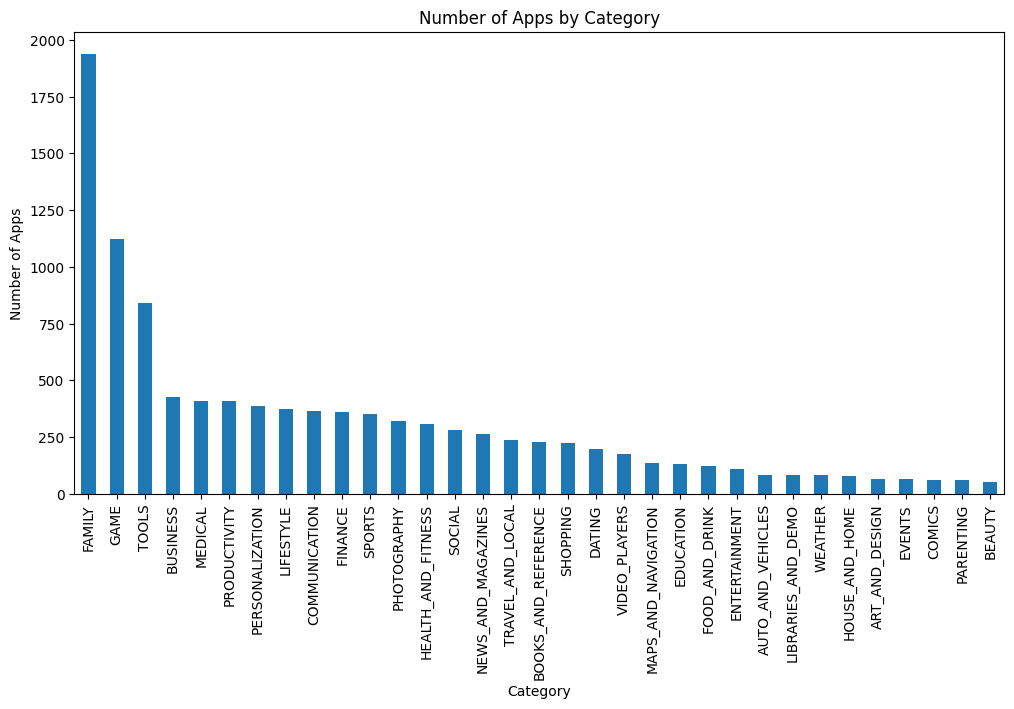

In [94]:
plt.figure(figsize=(12, 6))

category_counts.plot(kind="bar")
plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.show()

### Observation

The number of applications varies considerably across categories. Some categories contain a much larger number of applications than others, indicating that app development is concentrated in certain areas.

##  App Rating Analysis

Ratings are an important indicator of user satisfaction.
In this step, we will examine the distribution of app ratings and understand how ratings are spread across the applications.

In [95]:
print(df['Rating'].describe())

count    10346.00000
mean         4.20377
std          0.48573
min          1.00000
25%          4.10000
50%          4.30000
75%          4.50000
max          5.00000
Name: Rating, dtype: float64


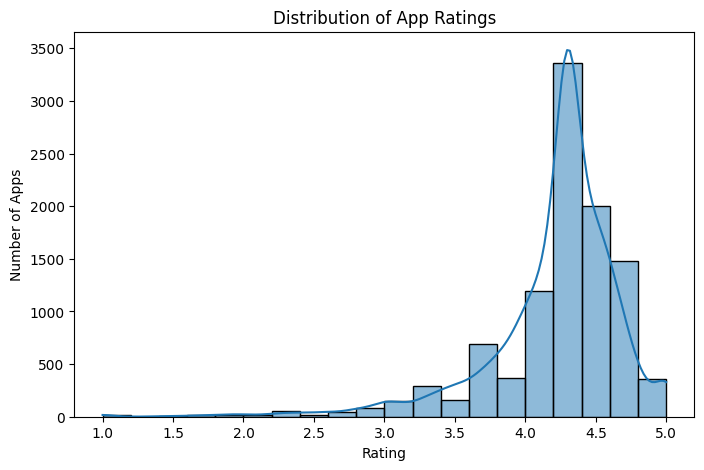

In [96]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Rating"], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

## Relationship Between Reviews and Ratings

In this step, we will analyze the relationship between the number of user reviews and the app rating.

In [ ]:
# Relationship between reviews and ratings

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Rating"
)

plt.title("Relationship Between Reviews and Ratings")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()

## Install Analysis

In this step, we will analyze the number of installations of applications.This will help us identify the most popular applications based on their number of installs.

In [ ]:
# Clean the Installs column

df["Installs"] = (
    df["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [ ]:
df["Installs"].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [ ]:
df.sort_values("Installs", ascending=False).drop_duplicates("App")[["App", "Category", "Installs"]].head(5)

,App,Category,Installs
5395,Google Photos,PHOTOGRAPHY,1000000000
4170,Google Drive,PRODUCTIVITY,1000000000
3117,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,1000000000
4153,Hangouts,COMMUNICATION,1000000000
3234,Google,TOOLS,1000000000


## Free vs Paid Applications

In this step, we will compare free and paid applications to understand the pricing distribution of apps on the Google Play Store.

In [ ]:
# Count Free and Paid applications

type_counts = df["Type"].value_counts()

print(type_counts)

Type
Free    9584
Paid     762
Name: count, dtype: int64


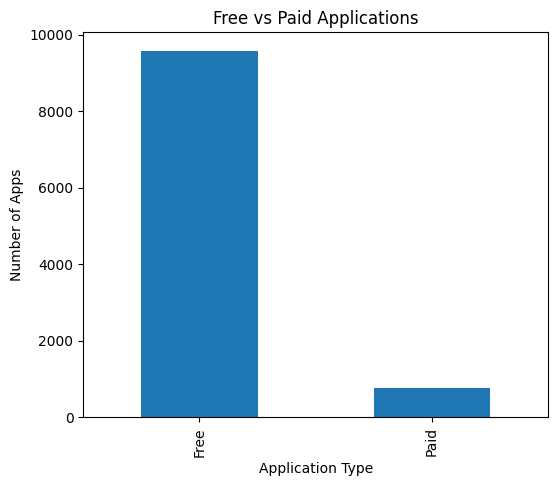

In [ ]:
plt.figure(figsize=(6, 5))

type_counts.plot(kind="bar")

plt.title("Free vs Paid Applications")
plt.xlabel("Application Type")
plt.ylabel("Number of Apps")

plt.show()

## Paid App Pricing and Estimated Revenue

In this step, we will analyze the prices of paid applications and estimate their potential revenue based on the number of installations.

In [ ]:
# Clean the Price column
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [ ]:
df["Price"].head

<bound method NDFrame.head of 0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
10836    0.0
10837    0.0
10838    0.0
10839    0.0
10840    0.0
Name: Price, Length: 10346, dtype: float64>

In [ ]:
# Calculate estimated revenue

df["Estimated Revenue"] = df["Price"] * df["Installs"]

In [ ]:
top_revenue_apps = df.sort_values(
    "Estimated Revenue",
    ascending=False
).drop_duplicates("App").head(10)

top_revenue_apps[["App", "Category", "Price", "Installs", "Estimated Revenue"]]

,App,Category,Price,Installs,Estimated Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,0.0,10000,0.0
1,Coloring book moana,ART_AND_DESIGN,0.0,500000,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,0.0,5000000,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,0.0,50000000,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,0.0,100000,0.0
5,Paper flowers instructions,ART_AND_DESIGN,0.0,50000,0.0
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,0.0,50000,0.0
7,Infinite Painter,ART_AND_DESIGN,0.0,1000000,0.0
8,Garden Coloring Book,ART_AND_DESIGN,0.0,1000000,0.0
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,0.0,10000,0.0


### Observation

Minecraft has the highest estimated revenue among the applications analyzed, with approximately $69.9 million based on its listed price and number of installs.

Some applications have very high prices but relatively few installations. This shows that both pricing and the number of installs influence estimated revenue.

The revenue values are theoretical estimates because the dataset provides approximate installation counts and does not indicate how many users actually purchased the paid application.

# Final Insights and Recommendations

## Key Insights

- The number of applications varies significantly across different categories.
- Free applications are much more common than paid applications.
- Most app ratings are concentrated in the higher rating range.
- A small number of applications have extremely high installation counts.
- Some applications have millions or even billions of installations.
- App categories differ in their average ratings.
- Both app price and number of installations influence estimated revenue.
- Some paid applications can generate high estimated revenue because of their combination of price and installations.

## Recommendations

1. Developers should focus on categories with strong user demand and high installation numbers.
2. User ratings should be monitored to maintain customer satisfaction.
3. Developers should study successful apps to understand factors associated with high installations.
4. Paid applications should balance pricing with expected market demand.
5. Installation numbers, ratings, and pricing should be considered together when evaluating app performance.

# Conclusion

The Google Play Store dataset was analyzed to understand application categories, ratings, reviews, installations, pricing, and estimated revenue.

The analysis included data cleaning, exploratory data analysis, data visualization, grouping and aggregation, and comparison of different app characteristics.

The results helped identify popular app categories, highly installed applications, differences between free and paid applications, and applications with high estimated revenue.

This project demonstrates how data analytics can be used to discover useful patterns from real-world application data and support data-driven decision making.